# Exercises 1
## 1.1

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2
import math as math

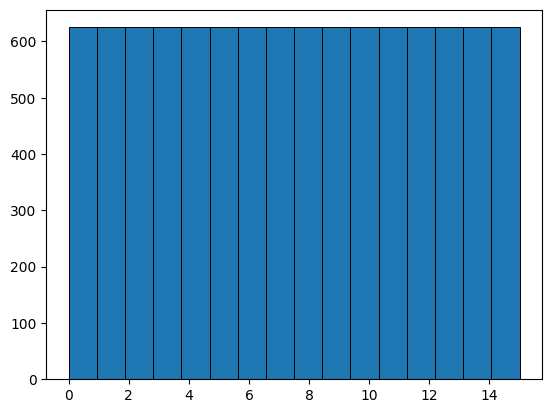

In [16]:
def lcg(n: int, a: int, c: int, x0:int = 42, M: int = 12):
    out = [x0]
    for _ in range(n-1):
        xi=(a*out[-1]+c)%M
        out.append(xi)
    return out

out = lcg(10000, 5, 1, 3, 16)

plt.hist(out, bins=16, edgecolor='black', linewidth=0.7)
plt.show()

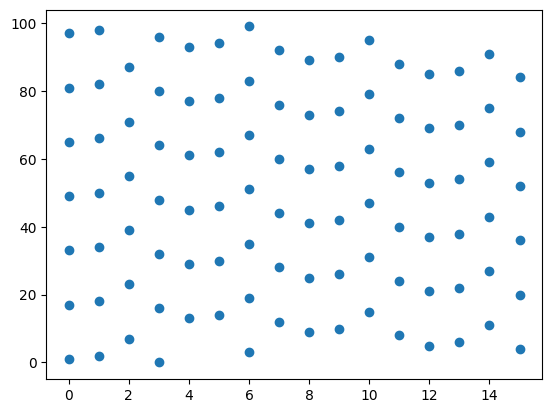

In [67]:
plt.scatter(out[0:100],range(100))
plt.show()

In [ ]:
def chi2Test(observed: list[int], bins: int, alpha: float = 0.05):
    expected = len(observed) / bins
    counts = pd.Series(observed).value_counts().reindex(range(bins), fill_value=0)
    chi_stat = ((counts - expected)**2 / expected).sum()

    df = bins - 1
    
    p_val = 1-chi2.cdf(chi_stat,df=df)
    crit_val = chi2.ppf(1-alpha,df=df)
    reject = chi_stat > crit_val
    print(f"Chi2 statistic:  {chi_stat:.4f}")
    print(f"Critical value:  {crit_val:.4f}  (alpha={alpha}, df={df})")
    print(f"p-value:         {p_val:.4f}")
    print(f"Reject H0:       {reject}")
    return chi_stat, p_val, reject
    
chi2Test(out,16)

Chi2 statistic:  0.0000
Critical value:  24.9958  (alpha=0.05, df=15)
p-value:         1.0000
Reject H0:       False


(np.float64(0.0), np.float64(1.0), np.False_)

In [21]:
def ks_test(observed: list[int], M: int, alpha: float = 0.05):
    n = len(observed)
    u = sorted(x / M for x in observed)

    d_plus  = max((i + 1) / n - u[i] for i in range(n))
    d_minus = max(u[i] - i / n       for i in range(n))
    D = max(d_plus, d_minus)

    c = {0.15: 1.138,0.10: 1.224, 0.05: 1.358, 0.01: 1.628}
    crit_val = c.get(alpha, 1.358) / math.sqrt(n)
    
    adjusted = (math.sqrt(n) + 0.12 + 0.11 / math.sqrt(n))*D
    
    reject = adjusted > crit_val

    print(f"KS statistic:    {D:.6f}")
    print(f"Adjusted stat:   {adjusted:.4f}")
    print(f"Critical value:  {crit_val:.6f}  (alpha={alpha}, n={n})")
    print(f"Reject H0:       {reject}")
    return D, reject

ks_test(out, 16)

KS statistic:    0.062500
Adjusted stat:   6.2576
Critical value:  0.013580  (alpha=0.05, n=10000)
Reject H0:       True


(0.0625, True)

In [37]:
def run_test1(observed: list[int], alpha: float = 0.05):
    median = sorted(observed)[len(observed) // 2]

    # Label each value as +1 (above) or -1 (below), skip ties
    signs = [1 if x > median else -1 for x in observed if x != median]

    n1 = signs.count(1)   # above
    n2 = signs.count(-1)  # below
    n  = n1 + n2

    # Count runs
    runs = []
    length = 1
    for i in range(1, len(signs)):
        if signs[i] == signs[i - 1]:
            length += 1
        else:
            runs.append(length)
            length = 1
    runs.append(length)
    R = len(runs)

    mu    = (2 * n1 * n2) / n + 1
    var = math.sqrt((2 * n1 * n2 * (2 * n1 * n2 - n)) / (n**2 * (n - 1)))
    Z = (R - var) / var

    p_value = math.erfc(abs(Z) / math.sqrt(2))

    z_crit = {0.10: 1.645, 0.05: 1.960, 0.01: 2.576}
    crit_val = z_crit.get(alpha, 1.960)

    reject = abs(Z) > crit_val
    print(f"Median:             {median}")
    print(f"n1 (above):         {n1},        n2 (below): {n2}")
    print(f"Runs:               {R}")
    print(f"Avg run length:     {sum(runs)/R:.4f}")
    print(f"Max run length:     {max(runs)}")
    print(f"Expected runs:      {mu:.2f}  (std={var:.2f})")
    print(f"Z statistic:        {Z:.4f}")
    print(f"Critical value +-:  {crit_val}  (alpha={alpha})")
    print(f"p-value:            {p_value:.4f}")
    print(f"Reject H0:          {reject}")
    return R, Z, p_value, reject#, runs

run_test1(out)

Median:             8
n1 (above):         4375,        n2 (below): 5000
Runs:               3750
Avg run length:     2.5000
Max run length:     4
Expected runs:      4667.67  (std=48.19)
Z statistic:        76.8097
Critical value +-:  1.96  (alpha=0.05)
p-value:            0.0000
Reject H0:          True


(3750, 76.80965646852152, 0.0, True)

In [ ]:
def run_test2(observed: list[int], alpha: float = 0.05):
    n = len(observed)

    signs = []
    for i in range(1, n):
        if observed[i] > observed[i - 1]:
            signs.append(1)
        elif observed[i] < observed[i - 1]:
            signs.append(-1)

    runs = []
    length = 1
    for i in range(1, len(signs)):
        if signs[i] == signs[i - 1]:
            length += 1
        else:
            runs.append(length)
            length = 1
    runs.append(length)

    R = len(runs)

    # Knuth's formulas — n is the original sequence length
    mu    = (2 * n - 1) / 3
    sigma = math.sqrt((16 * n - 29) / 90)
    Z     = (R - mu) / sigma

    p_value  = math.erfc(abs(Z) / math.sqrt(2))
    z_crit   = {0.10: 1.645, 0.05: 1.960, 0.01: 2.576}
    crit_val = z_crit.get(alpha, 1.960)

    # Run length distribution (Knuth groups length >= 6)
    length_counts = {k: 0 for k in range(1, 7)}
    for l in runs:
        length_counts[min(l, 6)] += 1

    reject = abs(Z) > crit_val
    print(f"n:               {n}")
    print(f"Runs (R):        {R}")
    print(f"Run length dist: { {k: length_counts[k] for k in range(1, 7)} }")
    print(f"Avg run length:  {sum(runs)/R:.4f}")
    print(f"Max run length:  {max(runs)}")
    print(f"Expected runs:   {mu:.2f}  (std={sigma:.2f})")
    print(f"Z statistic:     {Z:.4f}")
    print(f"Critical value:  {crit_val}  (alpha={alpha})")
    print(f"p-value:         {p_value:.4f}")
    print(f"Reject H0:       {reject}")
    return R, Z, p_value, reject

run_test2([0.54, 0.67, 0.13, 0.89, 0.33, 0.45, 0.90, 0.01, 0.45, 0.76, 0.82, 0.24, 0.17])


8 8.333333333333334 1.4102797200870787
n:               13
Runs (R):        8
Run length dist: {1: 5, 2: 2, 3: 1, 4: 0, 5: 0, 6: 0}
Avg run length:  1.5000
Max run length:  3
Expected runs:   8.33  (std=1.41)
Z statistic:     -0.2364
Critical value:  1.96  (alpha=0.05)
p-value:         0.8132
Reject H0:       False


(8, -0.23635972962353313, 0.8131535420563127, False)

In [64]:

def runs_test2(observed: list, alpha: float = 0.05):
    n = len(observed)

    # Build sign sequence: +1 if up, -1 if down (skip ties)
    signs = []
    for i in range(1, n):
        if observed[i] > observed[i - 1]:
            signs.append(1)
        elif observed[i] < observed[i - 1]:
            signs.append(-1)

    # Collect runs and their lengths
    runs = []
    length = 1
    for i in range(1, len(signs)):
        if signs[i] == signs[i - 1]:
            length += 1
        else:
            runs.append(length)
            length = 1
    runs.append(length)

    R = len(runs)
    m = len(signs)
    mu    = (2 * m - 1) / 3
    sigma = math.sqrt((16 * m - 29) / 90)
    Z = (R - mu) / sigma
    print(R,mu,sigma)
    

    p_value = math.erfc(abs(Z) / math.sqrt(2))

    z_crit = {0.10: 1.645, 0.05: 1.960, 0.01: 2.576}
    crit_val = z_crit.get(alpha, 1.960)

    reject = abs(Z) > crit_val
    print(f"Runs:            {R}")
    print(f"Avg run length:  {sum(runs)/R:.4f}")
    print(f"Max run length:  {max(runs)}")
    print(f"Expected runs:   {mu:.2f}  (std={sigma:.2f})")
    print(f"Z statistic:     {Z:.4f}")
    print(f"Critical value:  ±{crit_val}  (alpha={alpha})")
    print(f"p-value:         {p_value:.4f}")
    print(f"Reject H0:       {reject}")
    return R, Z, p_value, reject, runs

runs_test2([0.54, 0.67, 0.13, 0.89, 0.33, 0.45, 0.90, 0.01, 0.45, 0.76, 0.82, 0.24, 0.17])


8 7.666666666666667 1.3457752825457567
Runs:            8
Avg run length:  1.5000
Max run length:  3
Expected runs:   7.67  (std=1.35)
Z statistic:     0.2477
Critical value:  ±1.96  (alpha=0.05)
p-value:         0.8044
Reject H0:       False


(8, 0.24768870230903473, 0.8043752737972432, False, [1, 1, 1, 1, 2, 1, 3, 2])

In [55]:
def run_test3(observed: list, alpha: float = 0.05):
    n = len(observed)

    # Sign sequence, skip ties
    signs = []
    for i in range(1, n):
        if observed[i] > observed[i - 1]:
            signs.append(1)
        elif observed[i] < observed[i - 1]:
            signs.append(-1)

    # Collect run lengths
    runs = []
    length = 1
    for i in range(1, len(signs)):
        if signs[i] == signs[i - 1]:
            length += 1
        else:
            runs.append(length)
            length = 1
    runs.append(length)

    # R vector: counts of runs of length 1,2,3,4,5,>=6
    R = [0] * 6
    for l in runs:
        R[min(l, 6) - 1] += 1

    # B[k] = (k²+k-1) / (k+2)!  for k=1..5;  B[5] = 0.5 - sum(B[0:5])
    B = [(k**2 + k - 1) / math.factorial(k + 2) for k in range(1, 6)]
    B.append(0.5 - sum(B))

    # A is Knuth's precomputed inverse covariance matrix (Table 1, TAOCP Vol.2)
    A = [
        [4529.4, 9044.9, 13568,  18091,  22615,  27892 ],
        [9044.9, 18097,  27139,  36187,  45234,  55789 ],
        [13568,  27139,  40721,  54281,  67852,  83685 ],
        [18091,  36187,  54281,  72414,  90470,  111580],
        [22615,  45234,  67852,  90470,  113262, 139476],
        [27892,  55789,  83685,  111580, 139476, 172860],
    ]

    # d = R - n*B
    d = [R[i] - n * B[i] for i in range(6)]

    # Ad = A @ d
    Ad = [sum(A[i][j] * d[j] for j in range(6)) for i in range(6)]

    # Z = (1/(n-6)) * d^T * Ad
    Z = sum(d[i] * Ad[i] for i in range(6)) / (n - 6)

    p_value  = 1 - chi2.cdf(Z, df=6)
    crit_val = chi2.ppf(1 - alpha, df=6)

    reject = Z > crit_val
    print(f"R (run length counts): {dict(zip(range(1,7), R))}")
    print(f"E[R] = n*B:            {[round(n*b, 2) for b in B]}")
    print(f"Z statistic:           {Z:.4f}")
    print(f"Critical value:        {crit_val:.4f}  (chi2(6), alpha={alpha})")
    print(f"p-value:               {p_value:.4f}")
    print(f"Reject H0:             {reject}")
    return Z, p_value, reject

run_test3(out)


R (run length counts): {1: 3126, 2: 2499, 3: 625, 4: 0, 5: 0, 6: 0}
E[R] = n*B:            [1666.67, 2083.33, 916.67, 263.89, 57.54, 11.9]
Z statistic:           2025.9079
Critical value:        12.5916  (chi2(6), alpha=0.05)
p-value:               0.0000
Reject H0:             True


(2025.9078889107095, np.float64(0.0), np.True_)